# Notebook for creating NGBoost models

Feature selection is (somewhat) done in the feature selection notebook. However the only take away I could get was that having correlated features decreased model performance and than having a lot of features causes overfitting. The final features can be found in the "utils/fetch_data_for_NGBoost" 

On how to use NGBoost
https://stanfordmlgroup.github.io/ngboost/intro.html


In [ ]:
import sys
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle

from pathlib import Path
from ngboost import NGBRegressor
from sklearn.metrics import mean_squared_error
from ngboost.distns import LogNormal



# Add project root to sys.path
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))

from utils.fetch_training_data_for_NGBoost.mid import fetch_mid_data_for_NGBoost

Creating the model, and dooing some light hyperparameter tuning. 

In [2]:
np.random.seed(42)

X_train = fetch_mid_data_for_NGBoost(fetch_test_set=False)

y_train = X_train['total_points']
X_train = X_train.drop(columns=['total_points'])

X_test = fetch_mid_data_for_NGBoost(fetch_test_set=True)
y_test = X_test['total_points']
X_test = X_test.drop(columns=['total_points'])

HAUL_THRESHOLD = 6      # A player performance of 8 points or more is a "haul".
WEIGHT_MULTIPLIER = 5   # Give these instances more importance during training.

# Create the sample_weights array
sample_weights = np.ones(len(y_train))
sample_weights[y_train >= HAUL_THRESHOLD] = WEIGHT_MULTIPLIER


ngb_mid = NGBRegressor(verbose=True,         #Prits training progress
                       n_estimators=500,     # Number of boosting iterations
                       learning_rate=0.005, 
                       natural_gradient=True, 
                       minibatch_frac=0.7,
                       verbose_eval=100, 
                       early_stopping_rounds=12)

print("--- Training NGBoost Model for MID ---")
ngb_mid.fit(X_train, y_train, sample_weight=sample_weights)
print("--- Training Complete ---")

# Make predictions on the test set
y_preds = ngb_mid.predict(X_test)
y_dists = ngb_mid.pred_dist(X_test)

# Evaluate the model's performance
test_MSE = mean_squared_error(y_test, y_preds)

# Test Negative Log Likelihood (how well the predicted distributions match the actual outcomes)
test_NLL = -y_dists.logpdf(y_test.values).mean()

# Print the evaluation metrics
print(f"\n--- MID Model Evaluation ---")
print(f'Test MSE: {test_MSE:.4f}') # Mean Squared Error
print(f'Test NLL: {test_NLL:.4f}') # Negative Log Likelihood (How likely is the true outcome given the predicted distribution)

print(f"\n--- MID Evaluation On 20 highest scoring matches ---")
y_test_top20 = y_test.nlargest(20)
X_test_top20 = X_test.loc[y_test_top20.index]
y_preds_top20 = ngb_mid.predict(X_test_top20)
top20_MSE = mean_squared_error(y_test_top20, y_preds_top20)
top20_NLL = -ngb_mid.pred_dist(X_test_top20).logpdf(y_test_top20.values).mean()
print(f'Top 20 Test MSE: {top20_MSE:.4f}')
print(f'Top 20 Test NLL: {top20_NLL:.4f}')


c:\Users\trygt\fpl_dir\fpl_team_selector\utils\fetch_data_for_NGBoost\mid.py:15: DtypeWarning: Columns (39) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("../data/2024-25/gws/merged_gw.csv", usecols=mid_features)


--- Training NGBoost Model for MID ---
early_stopping_rounds is set to 12 but no validation set is provided creating val set with 0.1 of the training data
Creating validation set with sample weight similar to the training data
[iter 0] loss=3.2856 val_loss=3.2971 scale=1.0000 norm=2.1498
[iter 100] loss=2.8084 val_loss=2.8576 scale=1.0000 norm=2.3191
[iter 200] loss=2.7157 val_loss=2.7890 scale=1.0000 norm=2.5007
[iter 300] loss=2.6687 val_loss=2.7684 scale=1.0000 norm=2.6007
[iter 400] loss=2.6681 val_loss=2.7619 scale=1.0000 norm=2.6913
== Early stopping achieved.
== Best iteration / VAL428 (val_loss=2.7613)
--- Training Complete ---

--- MID Model Evaluation ---
Test MSE: 10.6390
Test NLL: 2.5435

--- MID Evaluation On 20 highest scoring matches ---
Top 20 Test MSE: 147.2664
Top 20 Test NLL: 6.8154


In [3]:
models_dir = Path('../models')
models_dir.mkdir(exist_ok=True)

file_path = models_dir / 'ngboost_mid_model.pkl'

try:
    with open(file_path, "wb") as f:
        pickle.dump(ngb_mid, f)
    print(f"Model successfully saved to: {file_path}")
except NameError:
    print("Error: The model object 'ngb_mid' was not found.")
    print("Please make sure you have trained the model in a previous cell.")
except Exception as e:
    print(f"An unexpected error occurred: {e}")

Model successfully saved to: ..\models\ngboost_mid_model.pkl


Looking at the feature importance of different features for the final model

In [4]:
## Feature importance for loc trees
feature_importance_loc = ngb_mid.feature_importances_[0]

## Feature importance for scale trees
feature_importance_scale = ngb_mid.feature_importances_[1]

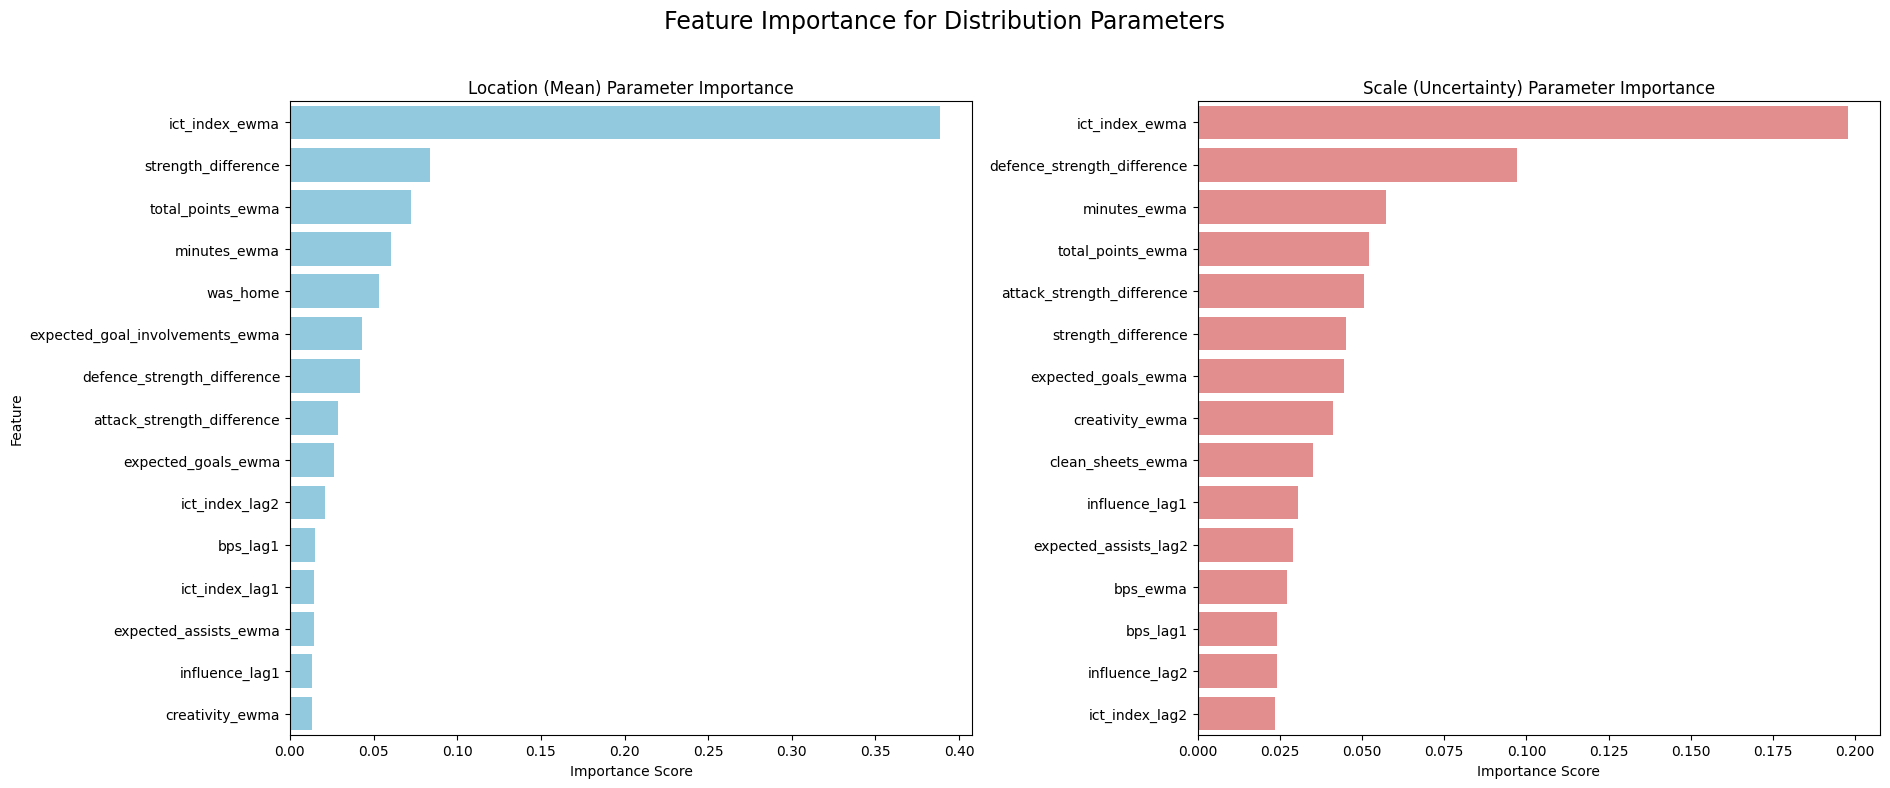

In [5]:
feature_names = X_train.columns

# Create a DataFrame for the 'loc' parameter importances
df_loc = pd.DataFrame({'feature': feature_names,
                       'importance': feature_importance_loc}) \
           .sort_values('importance', ascending=False)

# Create a DataFrame for the 'scale' parameter importances
df_scale = pd.DataFrame({'feature': feature_names,
                         'importance': feature_importance_scale}) \
             .sort_values('importance', ascending=False)

# Plotting
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(19, 8))
fig.suptitle("Feature Importance for Distribution Parameters", fontsize=17)

# Plot feature importance for the 'loc' parameter
sns.barplot(x='importance', y='feature', ax=ax1, data=df_loc.head(15), color="skyblue")
ax1.set_title('Location (Mean) Parameter Importance')
ax1.set_xlabel('Importance Score')
ax1.set_ylabel('Feature')

# Plot feature importance for the 'scale' parameter
sns.barplot(x='importance', y='feature', ax=ax2, data=df_scale.head(15), color="lightcoral")
ax2.set_title('Scale (Uncertainty) Parameter Importance')
ax2.set_xlabel('Importance Score')
ax2.set_ylabel('') # Hide y-axis label for clarity

# Improve layout and display the plot
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

#### Predictions vs Actuall points

Text(0, 0.5, 'Predicted Points')

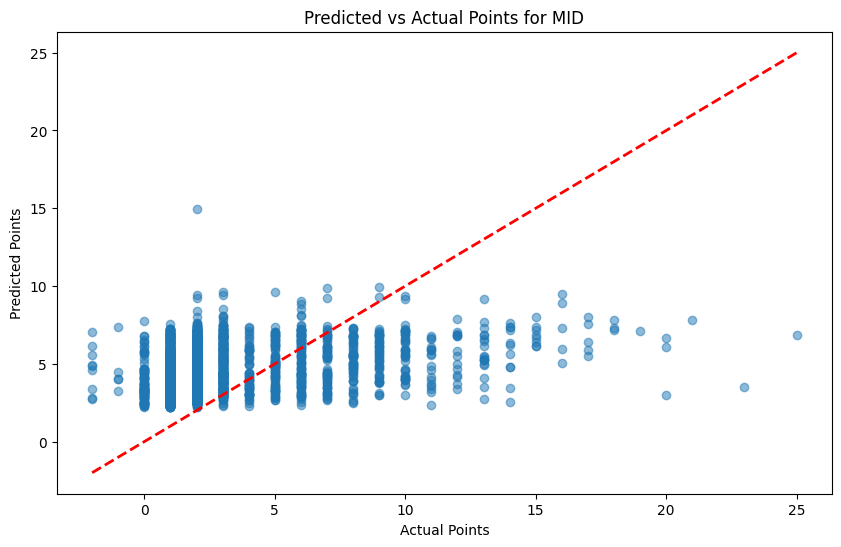

In [6]:
# Plotting y_pred against y_test
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_preds, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)  # Diagonal line
plt.title('Predicted vs Actual Points for MID')
plt.xlabel('Actual Points')
plt.ylabel('Predicted Points')

For the top 20 scoring players, looking at the predicted distribution

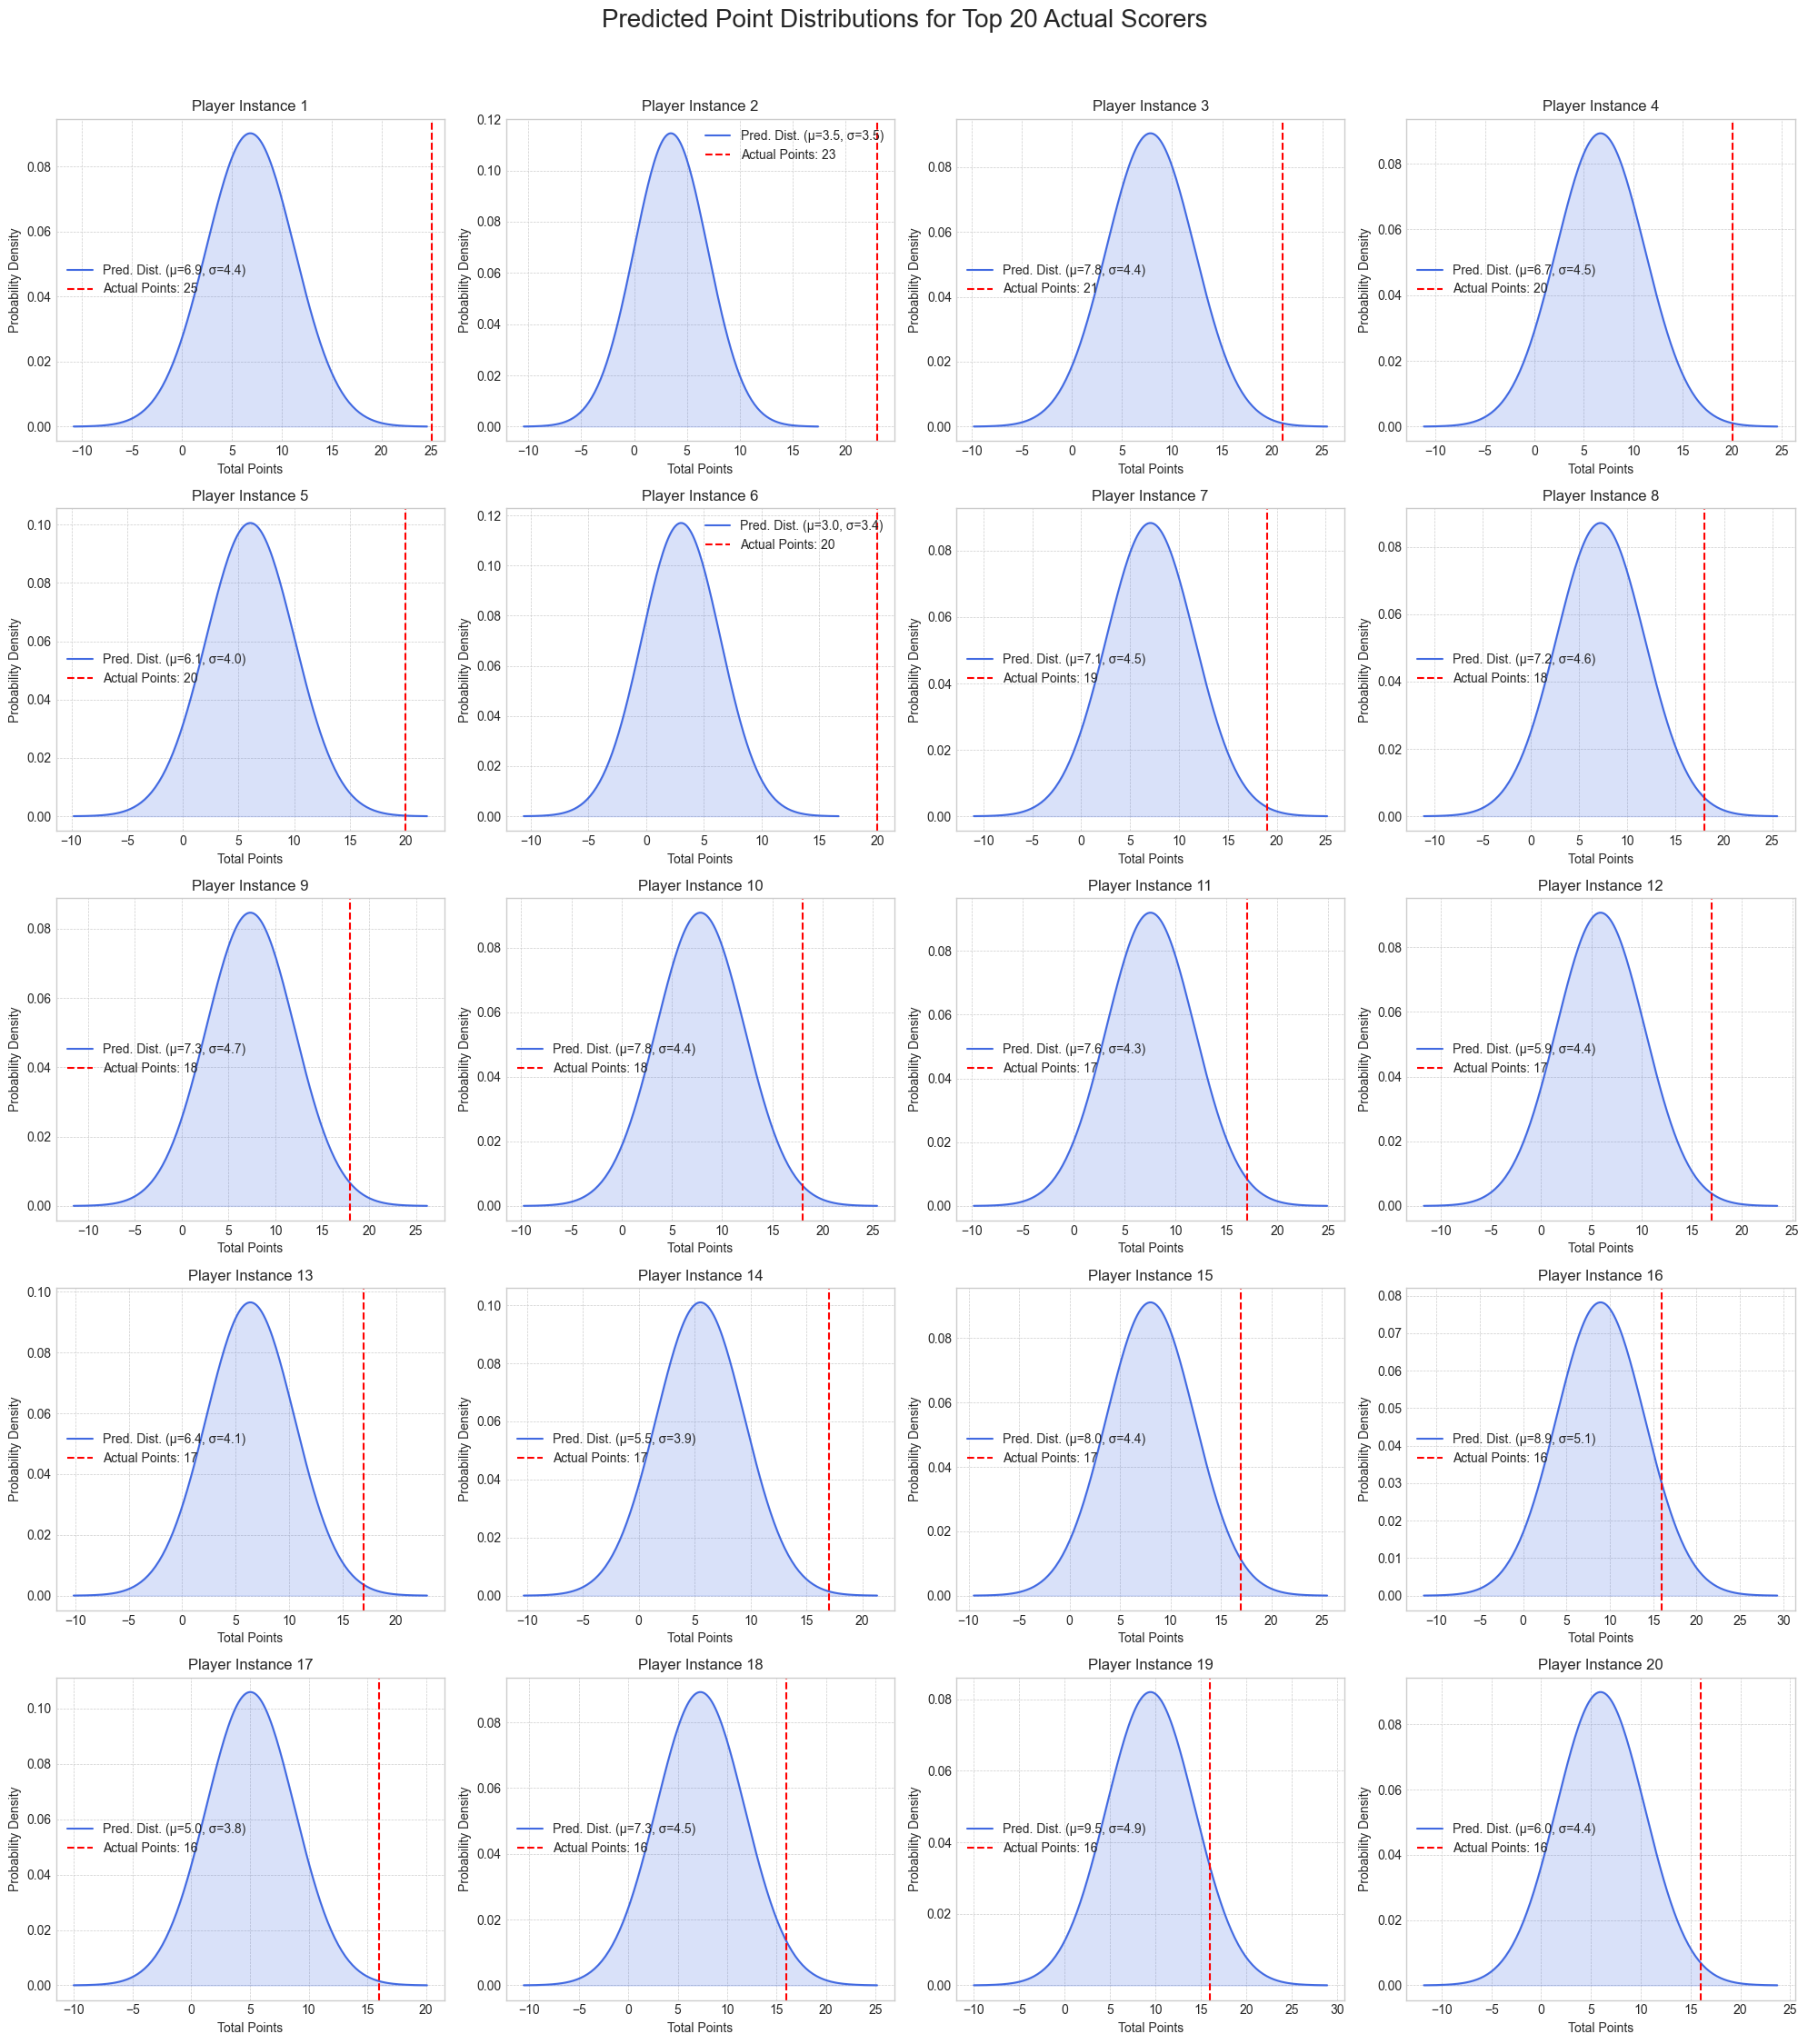

In [7]:
from scipy.stats import norm

# Ensure you have the trained model 'ngb_mid', X_test, and y_test in your environment

# Get Top 20 Highest Scoring Instances from the Test Set ---
y_test_top20 = y_test.nlargest(20)
X_test_top20 = X_test.loc[y_test_top20.index]

# Get Predicted Distributions for these Top 20 Players ---
y_dists_top20 = ngb_mid.pred_dist(X_test_top20)

# --- Plotting ---
plt.style.use('seaborn-v0_8-whitegrid')
fig, axes = plt.subplots(5, 4, figsize=(20, 22))
fig.suptitle('Predicted Point Distributions for Top 20 Actual Scorers', fontsize=20, y=1.02)
axes = axes.ravel() # Flatten the 5x4 grid into a 1D array

for i, (idx, y_actual) in enumerate(y_test_top20.items()):
    ax = axes[i]
    
    # Get the predicted distribution parameters (loc=mean, scale=std. dev. for Normal)
    loc = y_dists_top20.loc[i]
    scale = y_dists_top20.scale[i]
    
    # Generate points for the PDF curve
    x = np.linspace(loc - 4*scale, loc + 4*scale, 200)
    pdf = norm.pdf(x, loc=loc, scale=scale)
    
    # Plot the predicted distribution
    ax.plot(x, pdf, color='royalblue', label=f'Pred. Dist. (μ={loc:.1f}, σ={scale:.1f})')
    ax.fill_between(x, pdf, alpha=0.2, color='royalblue')
    
    # Mark the actual score with a vertical line
    ax.axvline(y_actual, color='red', linestyle='--', label=f'Actual Points: {y_actual:.0f}')
    
    ax.set_title(f'Player Instance {i+1}')
    ax.set_xlabel('Total Points')
    ax.set_ylabel('Probability Density')
    ax.legend()
    ax.grid(True, which='both', linestyle='--', linewidth=0.5)

plt.tight_layout()
plt.show()

In [8]:
# Clean up variables to free memory
del X_train, y_train, X_test, y_test, y_preds, y_dists, y_test_top20, X_test_top20, y_dists_top20, df_loc, df_scale, models_dir, file_path, ngb_mid
